In [3]:
import pandas as pd
from IPython.display import display
import dataframe_image as dfi
from typing import Sequence, Literal

UnitType  = Literal["phones", "sylls", "words"]
Metric    = Literal["IR", "ID", "SR"]
TextType  = Literal["within_words", "across_sentences"]
NVal      = Literal[1, 2, 3, 4]

def get_IR_ID_SR_table(
    csv_path: str = "produced_data_large_corpus/inter_intra_comparison.csv",
    languages: Sequence[str] = ("DEU", "ENG", "FRA"),
    unit_types: Sequence[UnitType] = ("phones", "sylls", "words"),
    n_values: Sequence[NVal] = (1, 2, 3, 4),
    metrics: Sequence[Metric] = ("IR", "ID", "SR"),
    text_types: Sequence[TextType] = ("within_words", "across_sentences"),
) -> None:
    """
    Build and export a compact comparison table for IR/ID/SR across languages, units, and n-grams.

    Loads an aggregated CSV of results, reshapes it to *long form*, 
    extracts structured factors from column names, filters to the requested
    subsets, and constructs a pivot table with mean values. The table is both displayed
    (with consistent global color scaling) and exported as a PNG for reporting.

    Pipeline
    --------
    1) Load the CSV from ``csv_path`` and normalize column names.
    2) Filter rows to the requested ``languages``.
    3) Melt to long form (id-vars: ``["Speaker", "Language", "Text"]``) to obtain a
       single ``Value`` column and a temporary ``MetricType`` column.
    4) Parse ``MetricType`` into factors:
         - ``TextType`` ∈ {``within_words``, ``across_sentences``}
         - ``UnitType`` ∈ {``phones``, ``sylls``, ``words``}
         - ``Metric``  ∈ {``IR``, ``ID``, ``SR``}
         - ``N`` ∈ {``unigram``, ``bigram``, ``trigram``, ``quadgram``} → mapped to
           integer ``n`` ∈ {1, 2, 3, 4}
    5) Apply user-selected filters on ``Language``, ``UnitType``, ``Metric``,
       ``TextType``, and ``n``.
    6) Pivot to a table with index ``["Language", "UnitType"]`` and columns
       ``["TextType", "Metric", "n"]``, aggregating by the mean of ``Value``.
    7) Determine global ``vmin``/``vmax`` from the filtered data to ensure a consistent
       color scale across all metrics and n-gram orders.
    8) Display a styled table (IPython) and export a PNG to ``images/`` via
       :mod:`dataframe_image` using matplotlib-based rendering.

    Parameters
    ----------
    csv_path : str, optional
        Filesystem path to the input CSV containing inter-/intra- comparisons. Defaults to
        ``"produced_data_large_corpus/inter_intra_comparison.csv"``.
    languages : Sequence[str], optional
        Language codes to include (e.g., ``("DEU","ENG","FRA")``). Used for row filtering
        *before* reshaping and aggregation.
    unit_types : Sequence[Literal["phones","sylls","words"]], optional
        Linguistic unit types to include in the summary.
    n_values : Sequence[Literal[1,2,3,4]], optional
        n-gram orders retained in the table (1=unigram, …, 4=quadgram).
    metrics : Sequence[Literal["IR","ID","SR"]], optional
        Metrics retained in the table columns.
    text_types : Sequence[Literal["within_words","across_sentences"]], optional
        Context scope(s) to include, as encoded in the input column names.

    Returns
    -------
    None
        The function displays the styled table in an interactive environment and exports a
        PNG to ``images/table_{languages}_{unit_types}_{n_values}_{metrics}_{text_types}.png``.

    Raises
    ------
    FileNotFoundError
        If ``csv_path`` does not exist.
    KeyError
        If required identifier columns (``"Speaker"``, ``"Language"``, ``"Text"``) are missing.
    ValueError
        If no columns match the expected naming convention
        ``{TextType}_{UnitType}_{Metric}_{N}`` (e.g., ``within_words_phones_IR_bigram``),
        or if filters exhaust all rows (empty pivot).

    Notes
    -----
    - **Expected column schema.** Besides ``"Speaker"``, ``"Language"``, and ``"Text"``,
      metric columns are expected to be named like
      ``{TextType}_{UnitType}_{Metric}_{N}``, where
      ``TextType ∈ {within_words, across_sentences}``,
      ``UnitType ∈ {phones, sylls, words}``,
      ``Metric ∈ {IR, ID, SR}``,
      and ``N ∈ {unigram, bigram, trigram, quadgram}``.
    - The color scale limits (``vmin``, ``vmax``) are computed from the filtered *long*
      data to permit fair cross-metric, cross-order comparisons in the pivot.
    """
    # Load CSV
    df = pd.read_csv(csv_path, encoding="utf-8")
    df.columns = df.columns.str.strip()


    # Filter languages
    df = df[df["Language"].isin(languages)]

    # Melt into long format
    df_long = df.melt(
        id_vars=["Speaker", "Language", "Text"],
        var_name="MetricType",
        value_name="Value"
    )

    # Extract components from MetricType
    metric_split = df_long["MetricType"].str.extract(
        r'(?P<TextType>within_words|across_sentences)_(?P<UnitType>phones|sylls|words)_(?P<Metric>ID|IR|SR)_(?P<N>unigram|bigram|trigram|quadgram)'
    )
    df_long = pd.concat([df_long.drop(columns=["MetricType"]), metric_split], axis=1)

    # Map n-gram labels to integers
    df_long["n"] = df_long["N"].map({
        "unigram": 1, "bigram": 2, "trigram": 3, "quadgram": 4
    })
    df_long = df_long.drop(columns="N")

    # Filter by selections
    df_long = df_long[
        (df_long["Language"].isin(languages)) &
        (df_long["UnitType"].isin(unit_types)) &
        (df_long["n"].isin(n_values)) &
        (df_long["Metric"].isin(metrics)) &
        (df_long["TextType"].isin(text_types))
    ]

    # Reorder for clarity
    df_long = df_long[["Language", "Speaker", "Text", "TextType", "UnitType", "Metric", "n", "Value"]]


    table = df_long.pivot_table(
        values="Value",
        index=["Language", "UnitType"],
        columns=["TextType", "Metric", "n"],
        aggfunc="mean"
    )

    #  Normalize the color gradient globally across the whole table
    vmin = df_long["Value"].min()
    vmax = df_long["Value"].max()

    # Display styled table
    display(
        table.style
        .set_table_styles(
            [{'selector': 'th', 'props': [('text-align', 'center')]}]
        )
        .set_properties(**{'text-align': 'center'})
        .background_gradient(cmap="Blues", vmin=vmin, vmax=vmax)
        .format("{:.2f}")
    )

    # Save styled table as PNG
    styled_table = (
        table.style
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
        .set_properties(**{'text-align': 'center'})
        .background_gradient(cmap="Blues", vmin=vmin, vmax=vmax)
        .format("{:.2f}")
    )
    # Save image 
    dfi.export(styled_table, f"images/table_{languages}_{unit_types}_{n_values}_{metrics}_{text_types}.png", table_conversion='matplotlib')


get_IR_ID_SR_table(
    csv_path="produced_data_large_corpus/inter_intra_comparison.csv",
    languages=['DEU', 'FRA', 'ENG'],
    unit_types=['sylls', 'words'],
    n_values=[1,2,3,4],
    metrics=["IR", "ID", "SR"],
    text_types=['across_sentences']
)


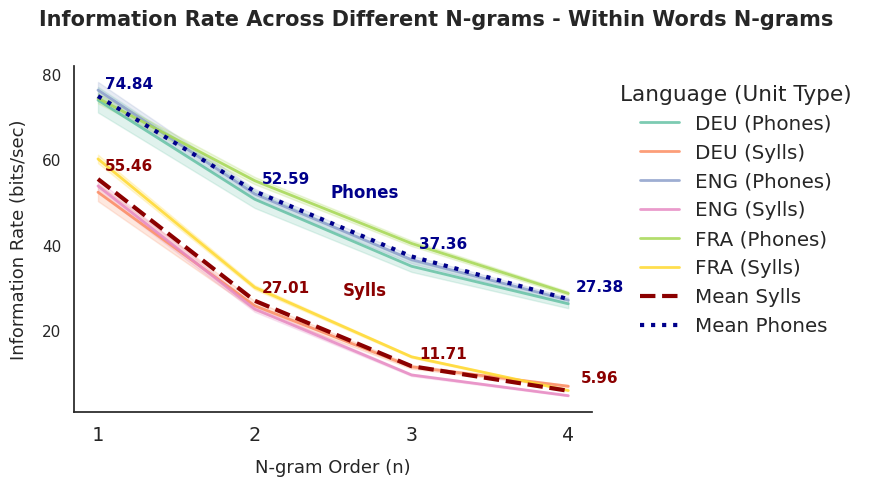

In [6]:
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Sequence

UnitType  = Literal["phones", "sylls", "words"]
Metric    = Literal["IR", "ID", "SR"]
TextType  = Literal["within_words", "across_sentences"]
NVal      = Literal[1, 2, 3, 4]

def plot_inforate_vs_ngram_order(
    text_type: TextType,
    unit_types: Sequence[UnitType],
    languages: Sequence[str],
) -> None:
    """
    Plot Information Rate (IR) as a function of n-gram order across languages and unit types.

    The function reads an aggregated results CSV, extracts the IR series for the requested
    ``text_type`` and ``unit_types``, reshapes to long form, maps n-gram labels to integer
    orders (1–4), and draws per-language curves with overlaid mean trajectories per unit type.
    It raises informative errors when the selection yields no plottable data.

    Pipeline
    --------
    1) Load ``produced_data_large_corpus/inter_intra_comparison.csv`` and strip column names.
    2) Filter rows to the selected ``languages``.
    3) For each entry in ``unit_types``:
         a) Collect IR columns matching
            ``{text_type}_{unit_type}_IR_{unigram|bigram|trigram|quadgram}``.
         b) Melt to long form and extract the n-gram order (map to integers 1–4).
         c) Keep only orders {1,2,3,4}; drop rows with missing order.
         d) Annotate the linguistic unit label and a combined ``Language_Unit`` key.
    4) Concatenate all unit-type frames, sort for readable legend order, and plot.
    5) Save PNG to ``images/IR_vs_ngram_order_{text_type}.png``.

    Parameters
    ----------
    text_type : Literal["within_words", "across_sentences"]
        Scope used in the input column naming scheme; selects which IR series to plot.
    unit_types : Sequence[Literal["phones", "sylls", "words"]]
        Linguistic unit types to include. Each unit type is rendered as multiple lines
        (one per language) plus an overlaid unit-wise mean trajectory.
    languages : Sequence[str]
        Language codes (e.g., ``["ENG", "FRA", "DEU"]``) to retain for plotting.

    Returns
    -------
    None

    Raises
    ------
    FileNotFoundError
        If the expected CSV is missing.
    KeyError
        If required identifier columns (``"Language"`` at minimum) are absent.
    ValueError
        If the language filter empties the dataset, if no IR columns exist for the
        requested combination(s), or if all unit types produce no valid rows after
        processing.
    """
    # --- Validate inputs at runtime (Literal is static-only) ---
    allowed_text = {"within_words", "across_sentences"}
    if text_type not in allowed_text:
        raise ValueError(f"Invalid text_type: {text_type}. Allowed: {sorted(allowed_text)}")

    allowed_units = {"phones", "sylls", "words"}
    bad_units = [u for u in unit_types if u not in allowed_units]
    if bad_units:
        raise ValueError(f"Invalid unit_types: {bad_units}. Allowed: {sorted(allowed_units)}")

    # --- Load and filter ---
    csv_path = "produced_data_large_corpus/inter_intra_comparison.csv"
    df = pd.read_csv(csv_path, encoding="utf-8", sep=",")  # FileNotFoundError propagates
    df.columns = df.columns.str.strip()

    if "Language" not in df.columns:
        raise KeyError('Required column "Language" is missing from the CSV.')

    df = df[df["Language"].isin(languages)]
    if df.empty:
        raise ValueError(f"No rows left after filtering for languages: {list(languages)}")

    # --- Style ---
    sns.set_context("notebook", font_scale=1.3)
    sns.set_style("white")
    plt.figure(figsize=(9, 5))

    # --- Collect data per unit type ---
    all_data = []
    missing_for_units = []   # track units that had no usable data

    ngram_order = {"unigram": 1, "bigram": 2, "trigram": 3, "quadgram": 4}

    for unit_type in unit_types:
        # Find IR columns for this unit and text_type
        IR_cols = [c for c in df.columns if c.startswith(f"{text_type}_{unit_type}_IR_")]
        if not IR_cols:
            missing_for_units.append(unit_type)
            continue  # try next unit_type

        # Prepare data
        df_IR = df[["Language"] + IR_cols].copy()
        df_IR_long = df_IR.melt(id_vars="Language", var_name="Metric", value_name="IR")

        # Extract n-gram order
        df_IR_long["n"] = df_IR_long["Metric"].str.extract(
            r"IR_(unigram|bigram|trigram|quadgram)"
        )
        df_IR_long["n"] = df_IR_long["n"].map(ngram_order)

        # Keep only n in {1,2,3,4}
        df_IR_long = df_IR_long[df_IR_long["n"].isin([1, 2, 3, 4])].dropna(subset=["n"])

        if df_IR_long.empty:
            missing_for_units.append(unit_type)
            continue

        # Add unit label and a combined key
        unit_name = unit_type.title()
        df_IR_long["Linguistic_Unit"] = unit_name
        df_IR_long["Language_Unit"] = df_IR_long["Language"] + " (" + unit_name + ")"

        all_data.append(df_IR_long)

    if not all_data:
        raise ValueError(
            "No valid IR data found for any requested unit type. "
            f"Checked unit_types: {list(unit_types)}; missing or empty: {missing_for_units}"
        )

    # --- Combine and plot ---
    df_combined = pd.concat(all_data, ignore_index=True)
    if df_combined.empty:
        raise ValueError("Combined dataset is empty after processing; cannot plot.")

    # Legend order
    df_combined = df_combined.sort_values(by=["Language_Unit", "n"])
    ordered_labels = df_combined["Language_Unit"].drop_duplicates().tolist()

    languages_units = df_combined["Language_Unit"].unique()
    custom_palette = sns.color_palette("Set2", n_colors=len(languages_units))

    sns.lineplot(
        data=df_combined,
        x="n", y="IR",
        hue="Language_Unit", hue_order=ordered_labels,
        palette=custom_palette,
        linewidth=2, alpha=0.85, linestyle="-"
    )

    # --- Overlay mean IR per unit type ---
    for unit_type in unit_types:
        unit_name = unit_type.title()
        df_unit = df_combined[df_combined["Linguistic_Unit"] == unit_name]
        if df_unit.empty:
            continue

        # Mean per language, then mean across languages per n
        lang_means = df_unit.groupby(["Language", "n"], as_index=False)["IR"].mean()
        df_mean = lang_means.groupby("n", as_index=False)["IR"].mean()

        color = "darkred" if unit_name == "Sylls" else "darkblue"
        linestyle = "--" if unit_name == "Sylls" else ":"

        sns.lineplot(
            data=df_mean, x="n", y="IR",
            color=color, label=f"Mean {unit_name}",
            linewidth=3, linestyle=linestyle
        )

        # Optional labels/annotations
        if len(df_mean) >= 2:
            mid_n = df_mean["n"].mean()
            mid_y = df_mean["IR"].mean() + 2.3
            plt.text(
                mid_n + 0.2, mid_y, f"{unit_name}",
                ha="center", va="bottom", fontsize=12, fontweight="bold", color=color
            )
        for _, row in df_mean.iterrows():
            plt.text(
                row["n"] + 0.2, row["IR"] + 1.2, f"{row['IR']:.2f}",
                ha="center", va="bottom", fontsize=11, fontweight="bold", color=color
            )

    # --- Final formatting ---
    label = text_type.replace("_", " ").title()
    plt.suptitle(
        f"Information Rate Across Different N-grams - {label} N-grams",
        fontsize=15, weight="bold", y=0.98, ha="center"
    )
    plt.xlabel("N-gram Order (n)", fontsize=13, labelpad=10)
    plt.ylabel("Information Rate (bits/sec)", loc="center", fontsize=13, labelpad=10)
    plt.xticks([1, 2, 3, 4], labels=["1", "2", "3", "4"], family="monospace")
    plt.yticks(fontsize=11)
    plt.legend(title="Language (Unit Type)", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    sns.despine()
    plt.grid(False)
    plt.tight_layout()

    # --- Save ---
    Path("images").mkdir(parents=True, exist_ok=True)
    out_path = Path("images") / f"IR_vs_ngram_order_{text_type}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_inforate_vs_ngram_order(
    text_type = "within_words",
    unit_types = ['sylls', 'phones'],
    languages = ['ENG', 'FRA', 'DEU']
) # Change as needed


Processing types: ['phones']


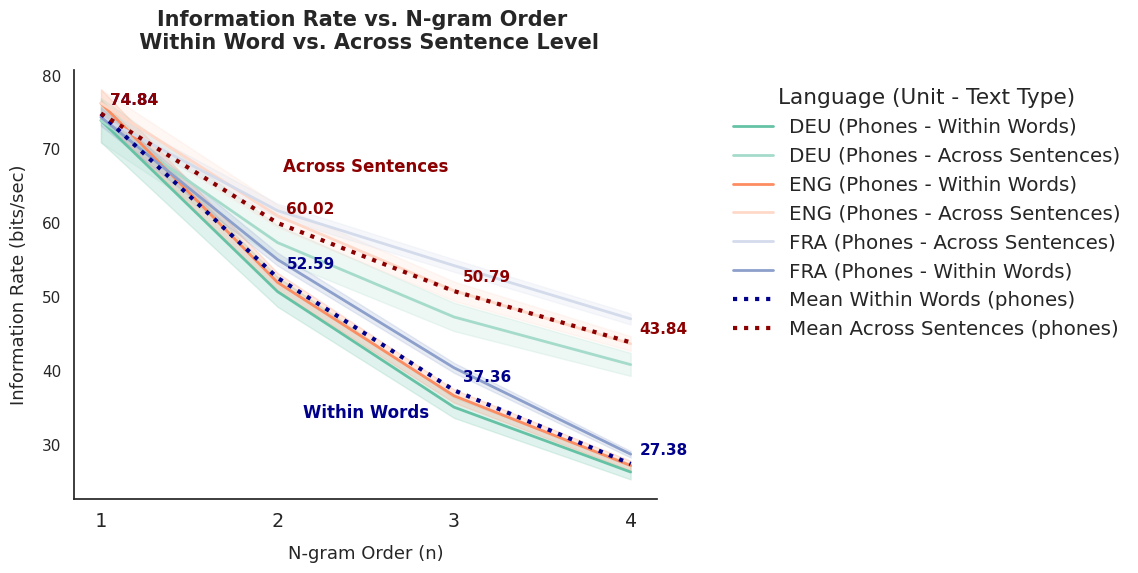

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_inforate_combined_texttypes(languages, processing_types):
    """
    Plot Information Rate vs. N-gram Order for both words and sentences in a single plot.
    Each line = unique combination of language, processing type, and text level.
    Adds mean line for each processing type + text level.
    """

    # Load and filter data
    df = pd.read_csv("produced_data_large_corpus/inter_intra_comparison.csv", encoding="utf-8", sep=",")
    df.columns = df.columns.str.strip()
    df = df[df["Language"].isin(languages)]

    all_data = []

    print(f"\nProcessing types: {processing_types}")
    for text_type in ["within_words", "across_sentences"]:
        for processing_type in processing_types:
            IR_cols = [col for col in df.columns if col.startswith(text_type) and processing_type in col and "IR_" in col]
            if not IR_cols:
                continue
            df_IR = df[["Language"] + IR_cols].copy()
            df_IR_long = df_IR.melt(id_vars="Language", var_name="Metric", value_name="IR")
            df_IR_long["n"] = df_IR_long["Metric"].str.extract(r"IR_(unigram|bigram|trigram|quadgram)")
            df_IR_long["n"] = df_IR_long["n"].map({"unigram": 1, "bigram": 2, "trigram": 3, "quadgram": 4})
            df_IR_long = df_IR_long.dropna(subset=["n"])
            df_IR_long["Linguistic_Unit"] = processing_type.title()
            df_IR_long["Text_Level"] = text_type 
            df_IR_long["Label"] = df_IR_long["Language"] + " (" + df_IR_long["Linguistic_Unit"] + " - " + text_type.replace('_', ' ').title() + ")"
            all_data.append(df_IR_long)

    if not all_data:
        print("No valid data found.")
        return

    df_combined = pd.concat(all_data, ignore_index=True)

    # Generate ordered labels for legend
    df_combined = df_combined.sort_values(by="Language")
    ordered_labels = df_combined["Label"].drop_duplicates().tolist()

    # Generate as many base colors as needed
    set2 = sns.color_palette("Set2", n_colors=12)

    # Get list of languages
    unique_languages = sorted(df_combined["Language"].unique())

    # Assign unique Set2 colors to languages
    language_to_base_color = dict(zip(unique_languages, set2[:len(unique_languages)]))

    def lighten_or_darken_color(color, factor=0.85):
        import matplotlib.colors as mc
        import colorsys
        """Lighten (factor > 1) or darken (factor < 1) an RGB color."""
        try:
            c = mc.cnames[color]
        except:
            c = color
        h, l, s = colorsys.rgb_to_hls(*mc.to_rgb(c))
        new_rgb = colorsys.hls_to_rgb(h, max(0, min(1, l * factor)), s)
        return new_rgb

    label_to_color = {}
    for lang in unique_languages:
        base = language_to_base_color[lang]
        for unit in df_combined["Linguistic_Unit"].unique():
            for text_level in ['within_words', 'across_sentences']:
                label = f"{lang} ({unit} - {text_level.replace('_', ' ').title()})"
                # Use original base color for within_words, modified version for across_sentences
                color = base if text_level == "within_words" else lighten_or_darken_color(base, factor=1.3)
                label_to_color[label] = color



    # Style and figure setup
    sns.set_context("notebook", font_scale=1.3)
    sns.set_style("white")
    plt.figure(figsize=(12, 6))


    # Plot individual lines as solid lines
    sns.lineplot(
        data=df_combined, x="n", y="IR", hue="Label",
        hue_order=ordered_labels,
        palette=label_to_color,
        linewidth=2, alpha=1.0, linestyle="-"
    )

    # Add mean lines per processing type and text level
    mean_keys = []

    for processing_type in processing_types:
        for text_level in ['within_words', 'across_sentences']:
            key = (processing_type.title(), text_level)
            mean_keys.append(key)

    for processing_type in processing_types:
        unit_name = processing_type.title()
        for text_level in ['within_words', 'across_sentences']:
            level_name = text_level
            df_unit = df_combined[
                (df_combined["Linguistic_Unit"] == unit_name) &
                (df_combined["Text_Level"] == level_name)
            ]
            if not df_unit.empty:
                df_mean = df_unit.groupby(["Language", "n"], as_index=False)["IR"].mean()
                df_mean = df_mean.groupby("n", as_index=False)["IR"].mean()
  
                # Set distinct color + style per type
                level_name = text_level.replace('_', ' ').title()
                key = (unit_name, text_level)
                color = "darkblue" if level_name == "Within Words" else "darkred"
                linestyle = "--" if unit_name == "Sylls" else ":"

                sns.lineplot(data=df_mean, x="n", y="IR", color=color,
                             label=f"Mean {level_name} ({processing_type})", linewidth=3, linestyle=linestyle)

                x_offset = 0.05
                y_offset = (df_combined["IR"].max() - df_combined["IR"].min()) * 0.015

                for _, row in df_mean.iterrows():
                    plt.text(row["n"] + x_offset, row["IR"] + y_offset, f"{row['IR']:.2f}",
                        color=color, fontsize=11, fontweight='bold')
                    
                # Label line in the middle 
                label = text_level.replace('_', ' ').title()
                if len(df_mean) >= 2:
                    mid_n = df_mean["n"].mean()
                    if text_level == 'across_sentences':
                        mid_y = df_mean["IR"].mean() +9 # vertical offset
                    else: 
                        mid_y = df_mean["IR"].mean() - 15 # vertical offset
                    plt.text(
                        mid_n,
                        mid_y,
                        label,
                        ha='center',
                        va='bottom',
                        fontsize=12,
                        fontweight='bold',
                        color=color
                    )

    # Customize plot
    plt.title("Information Rate vs. N-gram Order \n Within Word vs. Across Sentence Level",
              fontsize=15, weight='bold', pad=15)
    plt.xlabel("N-gram Order (n)", fontsize=13, labelpad=10)
    plt.ylabel("Information Rate (bits/sec)", fontsize=13, labelpad=10)
    plt.xticks([1, 2, 3, 4], labels=["1", "2", "3", "4"], family="monospace")
    plt.yticks(fontsize=11)
    plt.legend(title="Language (Unit - Text Type)", bbox_to_anchor=(1.1, 1), loc='upper left', frameon=False)
    sns.despine()
    plt.grid(False)
    plt.tight_layout()

    # Save and show
    plt.savefig("images/IR_vs_ngram_order_within_words_across_sentences.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_inforate_combined_texttypes(languages=["FRA", "DEU", "ENG"], processing_types=["phones"])
